# 05 — Visualise Author Seniority Distributions

This notebook shows how to visualise the results of the author enrichment pipeline from notebook 04. It recreates charts similar to those in `inspiration/EDA.ipynb` using the example dataset of 10 papers.

**Note:** Run notebook 04 first to generate `data/example_papers_author_enriched.csv`. If you haven't run notebook 04 yet, this notebook includes a small hard-coded demo so you can see the chart format.

Charts produced:
- Seniority distribution for first vs last authors
- Seniority by country income group (HIC vs LMIC)

For a full dataset analysis, see `inspiration/EDA.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Load enriched data

In [2]:
enriched_path = '../data/example_papers_author_enriched.csv'

if os.path.exists(enriched_path):
    df = pd.read_csv(enriched_path)
    print(f'Loaded enriched data: {df.shape}')
else:
    print('Enriched file not found — using demo data.')
    print('Run serpapi/04_batch_enrich_first_last_authors.ipynb first.')
    # Small demo dataset for illustration
    df = pd.DataFrame({
        'Title': ['Paper A', 'Paper B', 'Paper C', 'Paper D', 'Paper E', 'Paper F'],
        'first_author_seniority': ['early', 'mid', 'early', 'senior', 'mid', 'early'],
        'last_author_seniority': ['senior', 'senior', 'mid', 'senior', 'mid', 'senior'],
        'Country of standardized research organization': [
            'Egypt', 'Finland; Libya', 'Egypt; United States', 'Luxembourg; Kenya', 'Morocco', 'Bahrain; Ethiopia'
        ],
    })

df.head()

Loaded enriched data: (6, 16)


,Paper id,DOI,Title,PubYear,first_author_name,first_author_scholar_id,first_author_hindex,first_author_total_citations,first_author_consecutive_years,first_author_seniority,last_author_name,last_author_scholar_id,last_author_hindex,last_author_total_citations,last_author_consecutive_years,last_author_seniority
0,4,10.3390/s23031255,An Efficient Machine Learning-Based Emotional ...,2023,Lamiaa Abdel-Hamid,koRj9FkAAAAJ,NaN,NaN,0,early,NaN,p6iWwZEAAAAJ,6.0,573.0,4.0,mid
1,5,10.1038/s41598-023-35795-0,Machine learning explainability in nasopharyng...,2023,Rasheed Omobolaji Alabi,g5ojVjsAAAAJ,16.0,1447.0,5,mid,Antti A. Mäkitie,NaN,NaN,NaN,NaN,NaN
2,6,10.1016/j.ymeth.2023.08.008,Machine learning algorithms for prediction of ...,2023,Omar M Fahmy,mDBAZUIAAAAJ,NaN,NaN,0,early,Mahmoud Elsabahy,Ceu2gy0AAAAJ,42.0,8422.0,7.0,mid
3,7,10.1186/s12874-023-01837-4,Machine learning for predicting neurodegenerat...,2023,Gloria A. Aguayo,Et4FcxsAAAAJ,20.0,2384.0,4,mid,Guy Fagherazzi,EKz0WDUAAAAJ,90.0,28156.0,1.0,early
4,8,10.1038/s41598-023-31542-7,Explanatory predictive model for COVID-19 seve...,2023,Mariam Laatifi,D5AahlIAAAAJ,3.0,126.0,2,early,Mariam Naciri,Xgw8jpwAAAAJ,12.0,616.0,0.0,early


## 2. Seniority distribution: first vs last authors

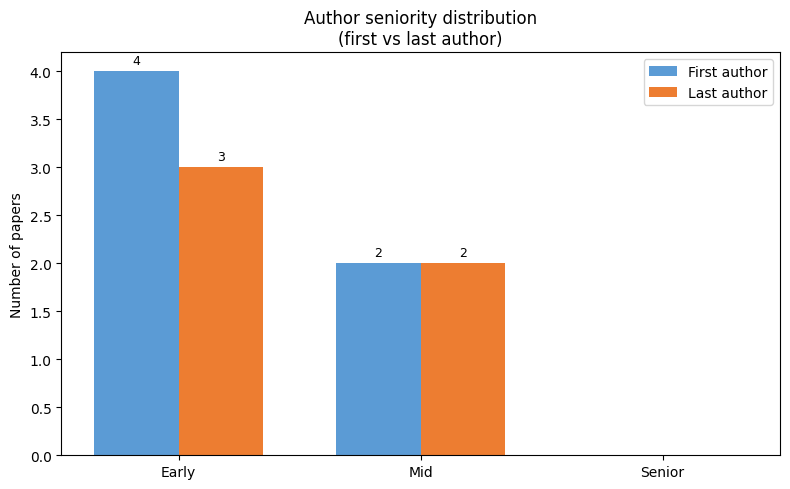

In [3]:
seniority_order = ['early', 'mid', 'senior']
colors = {'early': '#5B9BD5', 'mid': '#ED7D31', 'senior': '#70AD47'}

first_counts = df['first_author_seniority'].value_counts().reindex(seniority_order, fill_value=0)
last_counts = df['last_author_seniority'].value_counts().reindex(seniority_order, fill_value=0)

x = range(len(seniority_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([xi - width/2 for xi in x], first_counts, width, label='First author', color='#5B9BD5')
bars2 = ax.bar([xi + width/2 for xi in x], last_counts, width, label='Last author', color='#ED7D31')

ax.set_xticks(list(x))
ax.set_xticklabels([s.capitalize() for s in seniority_order])
ax.set_ylabel('Number of papers')
ax.set_title('Author seniority distribution\n(first vs last author)')
ax.legend()

# Add value labels
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3. HIC vs LMIC classification

We use the `Country of standardized research organization` column to identify papers with at least one author from a Low- or Middle-Income Country (LMIC) based on a simplified list.

In [4]:
# Simplified LMIC country list (World Bank classification)
LMIC_COUNTRIES = {
    'Egypt', 'Libya', 'Morocco', 'Kenya', 'Nigeria', 'Ethiopia', 'Algeria',
    'Ghana', 'Tanzania', 'Uganda', 'Senegal', 'Cameroon', 'Zimbabwe',
    'South Africa',  # upper-middle income — often classified separately
    'Bangladesh', 'Pakistan', 'India', 'Nepal', 'Cambodia',
    'Vietnam', 'Indonesia', 'Philippines',
}

def has_lmic_author(countries_str: str) -> bool:
    """Return True if any country in the semicolon-separated string is LMIC."""
    if pd.isna(countries_str):
        return False
    countries = [c.strip() for c in countries_str.split(';')]
    return any(c in LMIC_COUNTRIES for c in countries)


df['has_lmic'] = df['Country of standardized research organization'].apply(has_lmic_author)
df['hic_lmic'] = df['has_lmic'].map({True: 'LMIC', False: 'HIC'})

print('HIC / LMIC breakdown:')
print(df['hic_lmic'].value_counts())

KeyError: 'Country of standardized research organization'

In [ ]:
# First author seniority by HIC vs LMIC
seniority_by_group = df.groupby(['hic_lmic', 'first_author_seniority']).size().unstack(fill_value=0)
# Reorder columns
seniority_by_group = seniority_by_group.reindex(columns=[s for s in seniority_order if s in seniority_by_group.columns])

fig, ax = plt.subplots(figsize=(8, 5))
seniority_by_group.plot(kind='bar', ax=ax, color=['#5B9BD5', '#ED7D31', '#70AD47'])
ax.set_xlabel('Country income group')
ax.set_ylabel('Number of papers')
ax.set_title('First author seniority by country income group (HIC vs LMIC)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Seniority')
plt.tight_layout()
plt.show()

## 4. Scaling up

This notebook uses only 6 included papers from the example dataset. For a full scientometric analysis with hundreds of papers, see `inspiration/EDA.ipynb` which runs the same pipeline on the complete Dimensions export.

Key considerations when scaling:
- **API quota:** SerpAPI free tier provides 100 searches/month. A batch of 200 papers × 4 calls = 800 calls requires a paid plan.
- **Rate limiting:** Add `time.sleep(1)` between calls to avoid being throttled.
- **Caching:** Save intermediate results to CSV after each batch so you can resume if interrupted.
- **Author disambiguation:** Name-based search is imperfect — use ORCID from OpenAlex (notebook 03) as a more reliable identifier where available.